In [ ]:
!pip install azure-cognitiveservices-vision-customvision
!pip install opencv-python
!pip install pillow


1st step--> Search for Custom Vision
select Custom Vision Service.


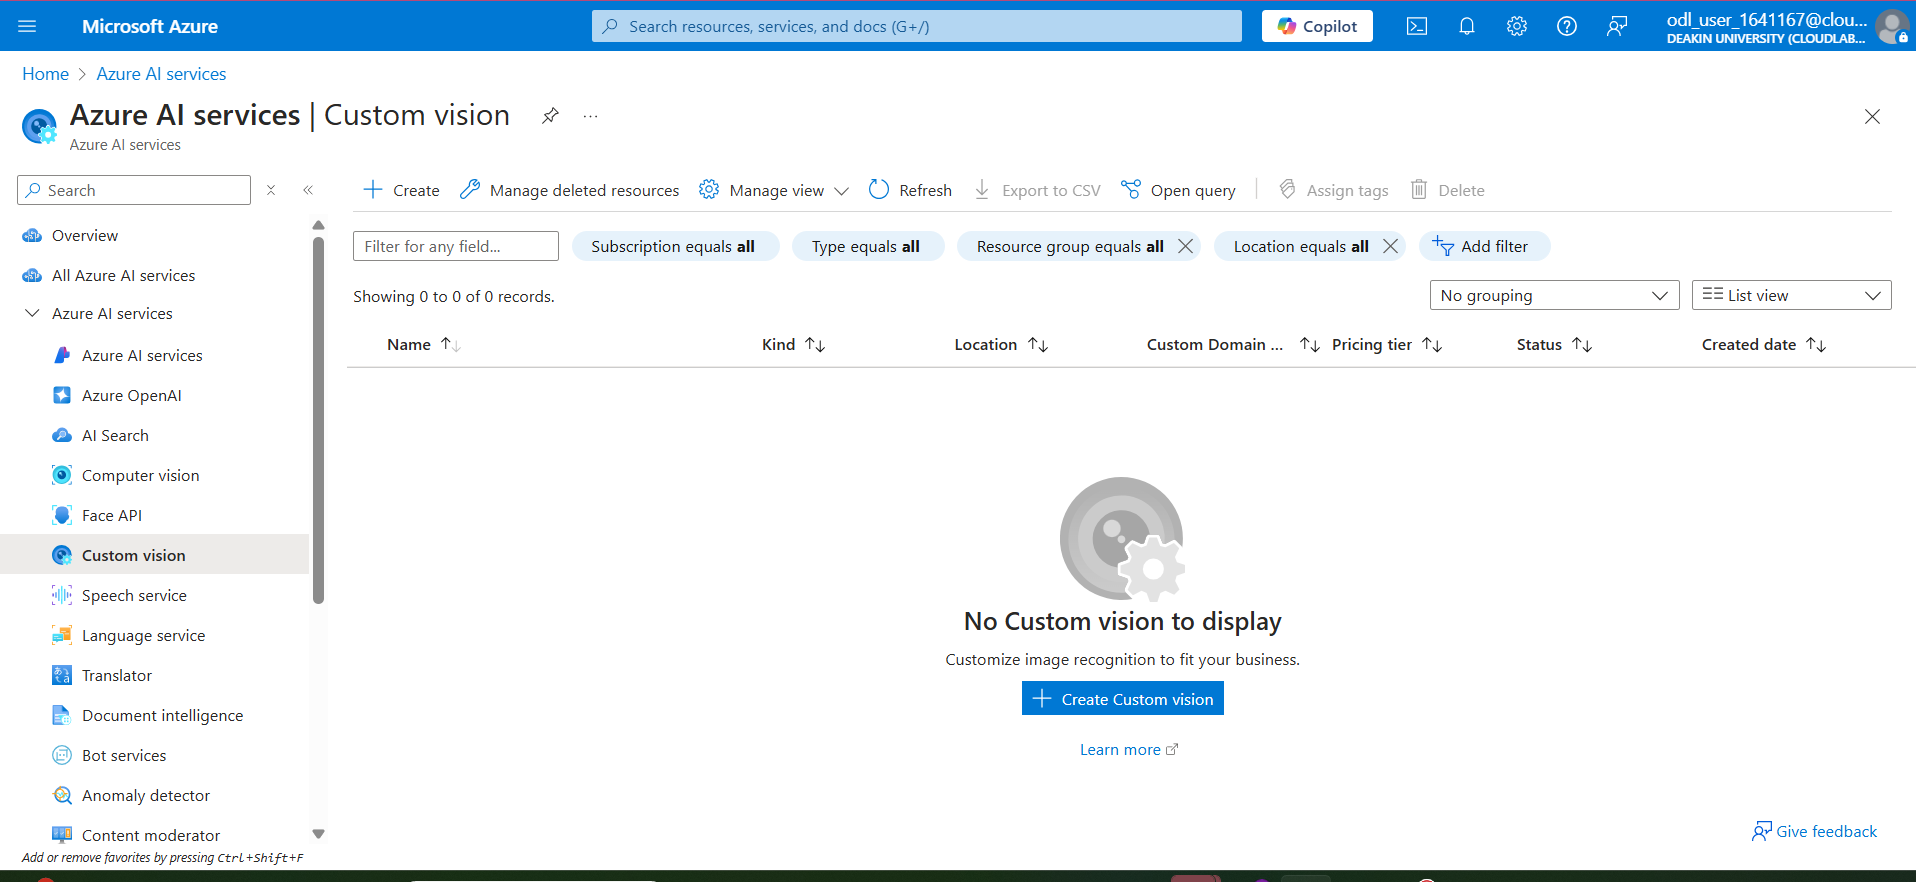

Click on create Custom Vision and fill names and select as per requirements
and at last review and create


Click on the resource 

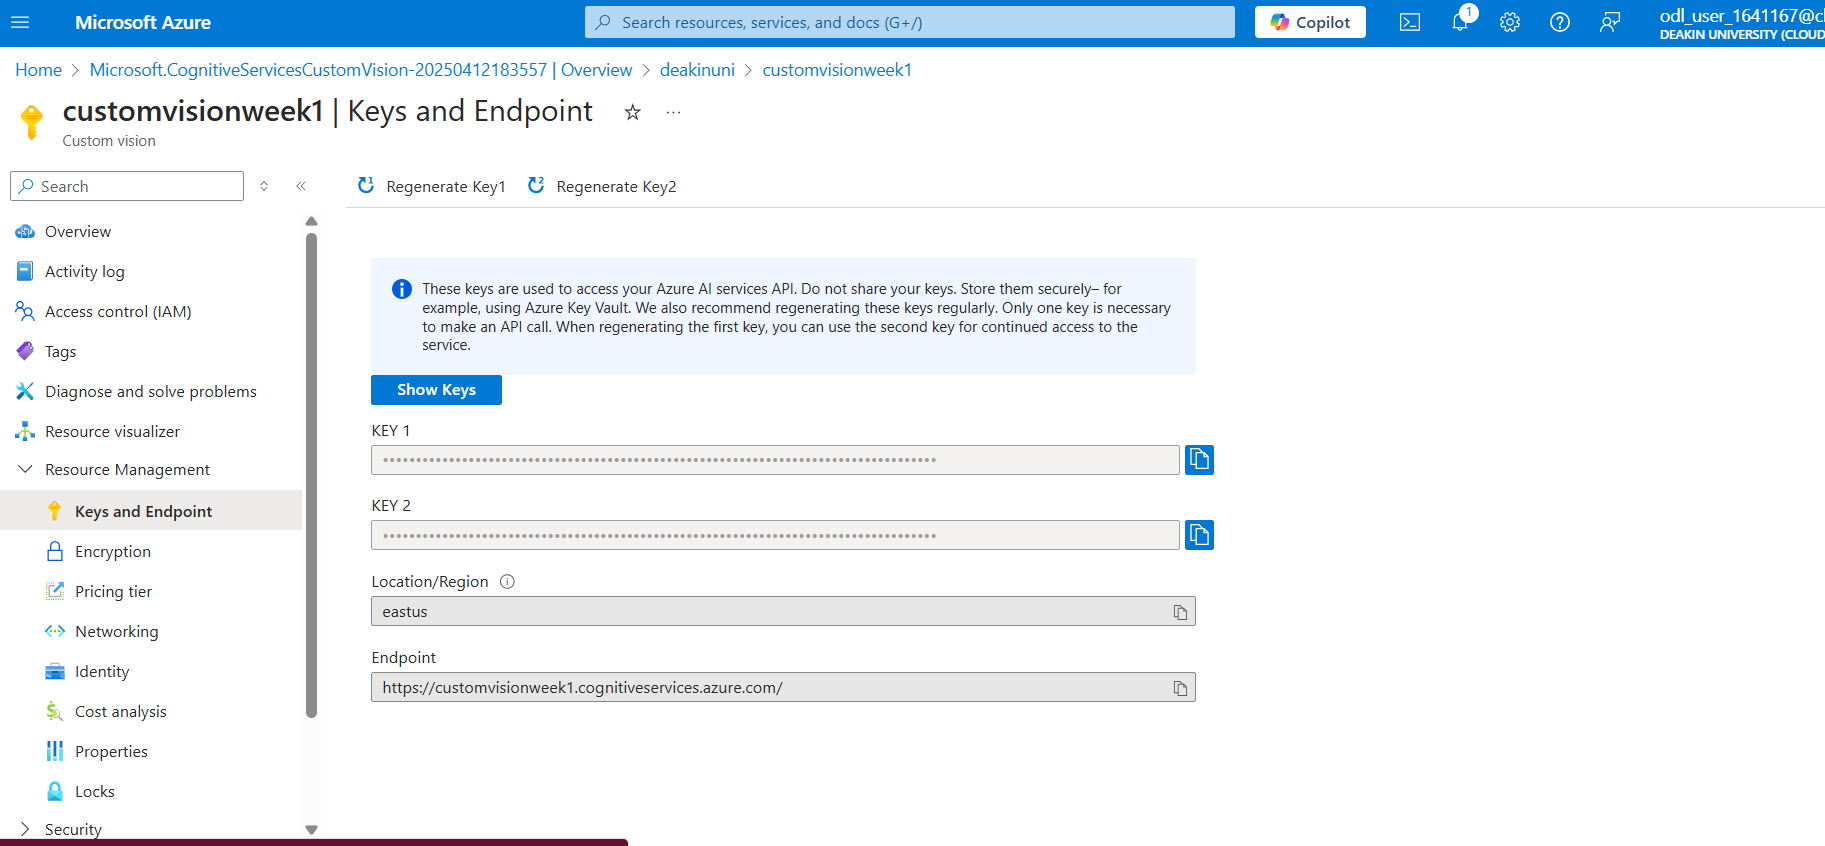

https://learn.microsoft.com/en-us/azure/ai-services/custom-vision-service/quickstarts/image-classification?tabs=windows%2Cvisual-studio&pivots=programming-language-python

Here you can find the keys and Endpoint

Go to overview

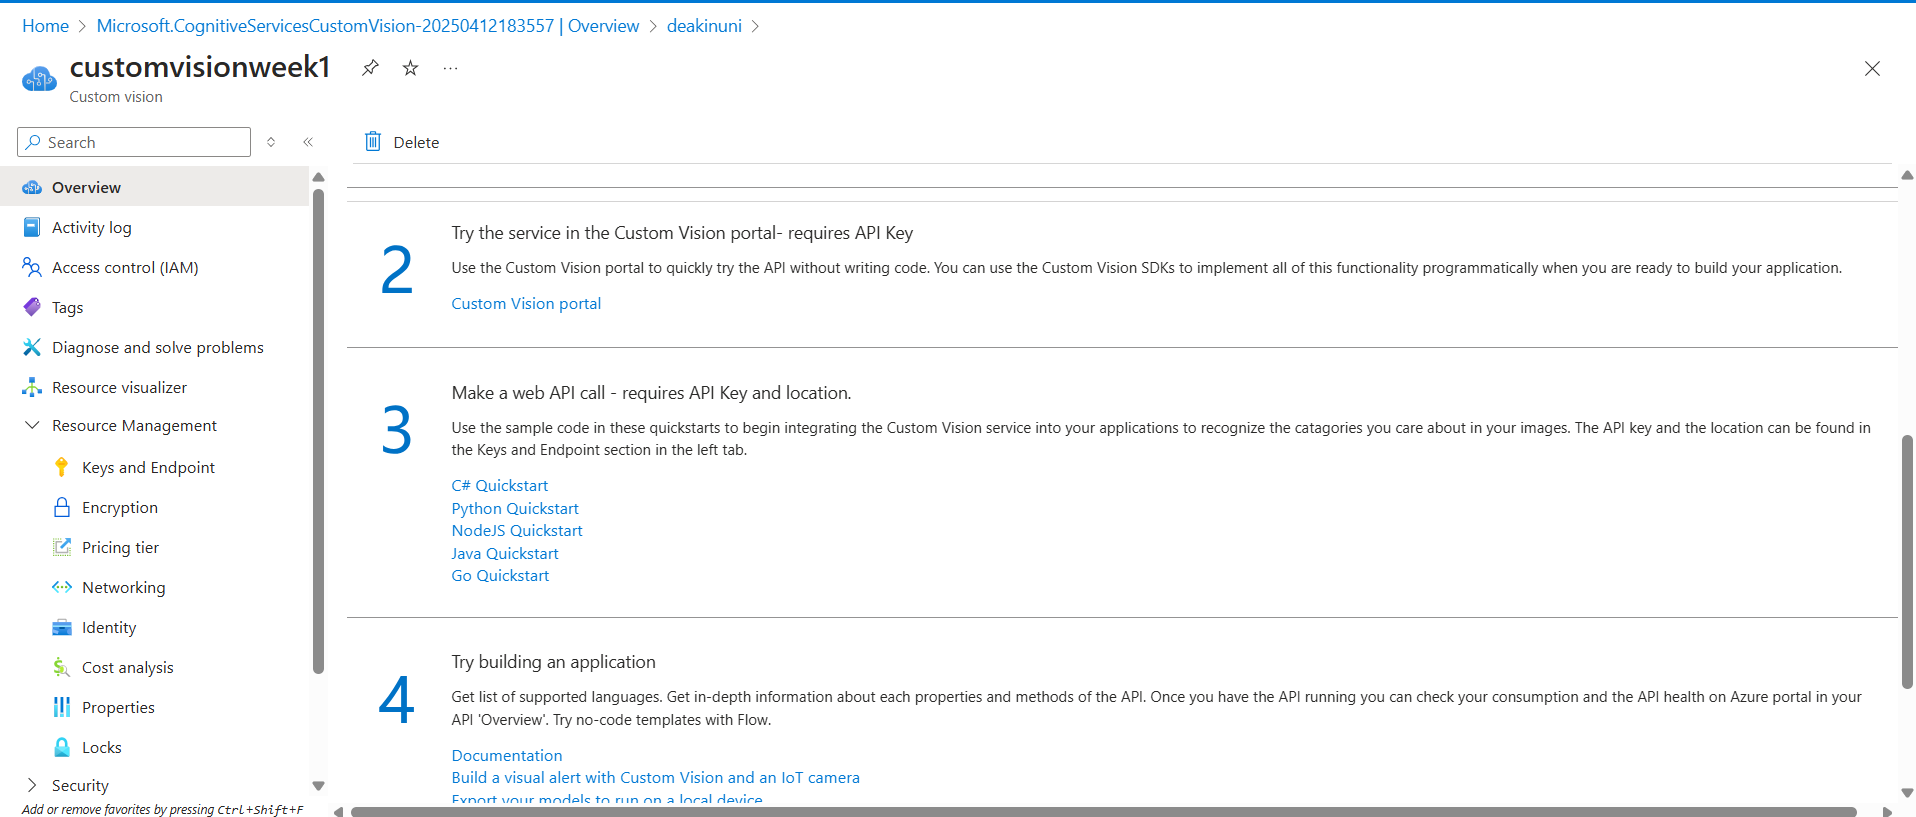

Click on Custom Vision portal as shown in number 2 above.

In [ ]:
from azure.cognitiveservices.vision.customvision.training import CustomVisionTrainingClient
from azure.cognitiveservices.vision.customvision.prediction import CustomVisionPredictionClient
from msrest.authentication import ApiKeyCredentials
import os 

In [ ]:

ENDPOINT = os.getenv("CUSTOM_VISION_ENDPOINT", "https://week05customvision.cognitiveservices.azure.com/")
training_key = os.getenv("CUSTOM_VISION_TRAINING_KEY", "your_training_key")
prediction_key = os.getenv("CUSTOM_VISION_PREDICTION_KEY", "your_prediction_key")
prediction_resource_id = os.getenv("CUSTOM_VISION_RESOURCE_ID", "subscriptions")

Authenticate the client


In [3]:
credentials = ApiKeyCredentials(in_headers={"Training-key": training_key})
trainer = CustomVisionTrainingClient(ENDPOINT, credentials)

prediction_credentials = ApiKeyCredentials(in_headers={"Prediction-key": prediction_key})
predictor = CustomVisionPredictionClient(ENDPOINT, prediction_credentials)

Create a new Custom Vision project


In [4]:
publish_iteration_name = "objectMovement"
obj_detection_domain = next(domain for domain in trainer.get_domains() if domain.type == "ObjectDetection" and domain.name == "General")
print("creating project ...")

project = trainer.create_project("week056customvision", domain_id=obj_detection_domain.id)
print(f"Computer vision project {project.id} is created successfully.")




creating project ...
Computer vision project 9c12a5af-58dd-41f3-9ecf-41c54102340b is created successfully.


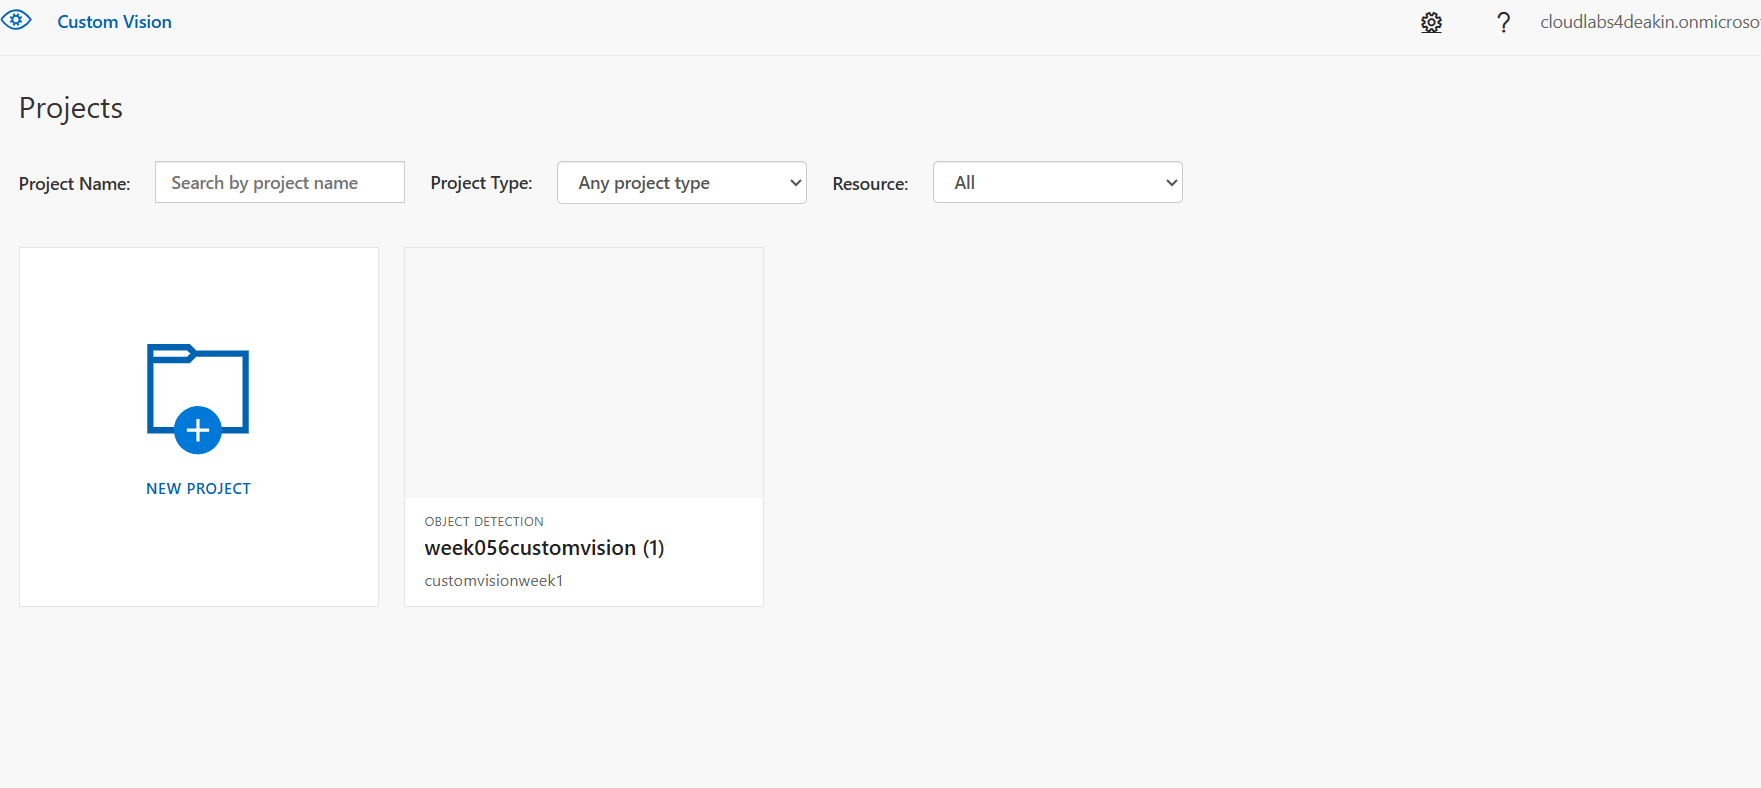

Project is created

In [5]:
project_name = "week056customvision"

# Get the domain
obj_detection_domain = next(
    domain for domain in trainer.get_domains()
    if domain.type == "ObjectDetection" and domain.name == "General"
)

# Try to find the existing project
existing_projects = trainer.get_projects()
project = next((p for p in existing_projects if p.name == project_name), None)

if project:
    print(f"Using existing project: {project.id}")
else:
    print("Project not found, creating a new one...")
    project = trainer.create_project(project_name, domain_id=obj_detection_domain.id)
    print(f"New computer vision project {project.id} created successfully.")


Using existing project: 907dbf79-6df6-48a5-a39b-28adba57efdb


Add tags to the project


Prepare Dataset 

In [ ]:
!pip install kagglehub

In [19]:
import kagglehub
import shutil
import os

# Define the destination path
destination_path = r"C:\Users\sachi\OneDrive\Documents\Deakin\2025 T2\SIT788_Engineering_sol\assignment\5.2D"

# Download the dataset
download_path = kagglehub.dataset_download("kaggleashwin/vehicle-type-recognition")

# Move the downloaded content to your target path
if not os.path.exists(destination_path):
    os.makedirs(destination_path)

for item in os.listdir(download_path):
    s = os.path.join(download_path, item)
    d = os.path.join(destination_path, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)
    else:
        shutil.copy2(s, d)

print("Dataset saved to:", destination_path)


100%|██████████| 159M/159M [01:35<00:00, 1.75MB/s] 

Extracting files...


Dataset saved to: C:\Users\sachi\OneDrive\Documents\Deakin\2025 T2\SIT788_Engineering_sol\assignment\5.2D


In [ ]:
!pip install --upgrade azure-cognitiveservices-vision-computervision


In [16]:

from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from azure.cognitiveservices.vision.computervision.models import VisualFeatureTypes
from msrest.authentication import CognitiveServicesCredentials
from PIL import Image, ImageDraw
import os
import time
from azure.cognitiveservices.vision.customvision.training.models import ImageFileCreateEntry, ImageFileCreateBatch
from azure.cognitiveservices.vision.customvision.training.models import Region

import math
# Step 1: Setup credentials
subscription_key = "99YNhPvfr2wVtM4SXJj9ddzAjFuucYxEidc8Z378qAjDnurASPylJQQJ99BDACYeBjFXJ3w3AAAFACOGUq8H"
endpoint = "https://week05-computervision.cognitiveservices.azure.com/"

def get_detected_regions(image_path: str, subscription_key: str, endpoint: str):
    """
    Detect objects in an image and return bounding box regions.

    Args:
        image_path (str): Local path to image.
        subscription_key (str): Azure Computer Vision subscription key.
        endpoint (str): Azure endpoint URL.

    Returns:
        List of dicts with label, x, y, width, height
    """

    # Authenticate client
    client = ComputerVisionClient(endpoint, CognitiveServicesCredentials(subscription_key))

    # Open image
    with open(image_path, "rb") as image_stream:
        results = client.analyze_image_in_stream(
            image=image_stream,
            visual_features=[VisualFeatureTypes.objects]
        )

    # Parse results
    regions = []
    for obj in results.objects:
        region = {
            "label": obj.object_property,
            "confidence": obj.confidence,
            "x": obj.rectangle.x,
            "y": obj.rectangle.y,
            "width": obj.rectangle.w,
            "height": obj.rectangle.h
        }
        regions.append(region)

    return regions

In [17]:

computervision_client = ComputerVisionClient(endpoint, CognitiveServicesCredentials(subscription_key))
cv_client = ComputerVisionClient(endpoint, CognitiveServicesCredentials(subscription_key))


# image_path = r"C:\Users\sachi\OneDrive\Documents\Deakin\2025 T2\SIT788_Engineering_sol\assignment\5.2D\Dataset\Bus\Image_1.jpg"

# regions = get_detected_regions(image_path, subscription_key, endpoint)

# for r in regions:
#     print(f"{r['label']} ({r['confidence']:.2f}) → x={r['x']}, y={r['y']}, w={r['width']}, h={r['height']}")

Creating a Tag

In [ ]:
from PIL import Image  # Make sure this is imported

base_image_path = "./Dataset"
car_tag = trainer.create_tag(project.id, "car")
bus_tag = trainer.create_tag(project.id, "bus")
motorcycle_tag = trainer.create_tag(project.id, "motorcycle")
truck_tag = trainer.create_tag(project.id, "truck")

tag_map = {
    "Bus": bus_tag,
    "Car": car_tag,
    "motorcycle": motorcycle_tag,
    "Truck": truck_tag
}

image_list = []
full_image_region_count = 0  # Count of fallback region uploads

for category, tag_obj in tag_map.items():
    category_folder = os.path.join(base_image_path, category)

    if not os.path.isdir(category_folder):
        print(f"⚠️ Folder not found: {category_folder}")
        continue

    for file_name in os.listdir(category_folder):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(category_folder, file_name)

            try:
                detected_regions = get_detected_regions(image_path, subscription_key, endpoint)

                region_entries = []
                for region in detected_regions:
                    if region["label"].lower() == category.lower():
                        region_entries.append(
                            Region(
                                tag_id=tag_obj.id,
                                left=region["left"],
                                top=region["top"],
                                width=region["width"],
                                height=region["height"]
                            )
                        )

                # Fallback: Add full-image region if no matching region found
                if not region_entries:
                    region_entries.append(
                        Region(
                            tag_id=tag_obj.id,
                            left=0.0,
                            top=0.0,
                            width=1.0,
                            height=1.0
                        )
                    )
                    full_image_region_count += 1
                    print(f"⚠️ No region match → used full image region for: {file_name}")

                with open(image_path, "rb") as image_file:
                    image_entry = ImageFileCreateEntry(
                        name=f"{category}_{file_name}",
                        contents=image_file.read(),
                        regions=region_entries
                    )
                    image_list.append(image_entry)

            except Exception as e:
                print(f"❌ Could not process {image_path}: {e}")


Once you create a tag for bus,motorcycle ,truck and car
u can see like this

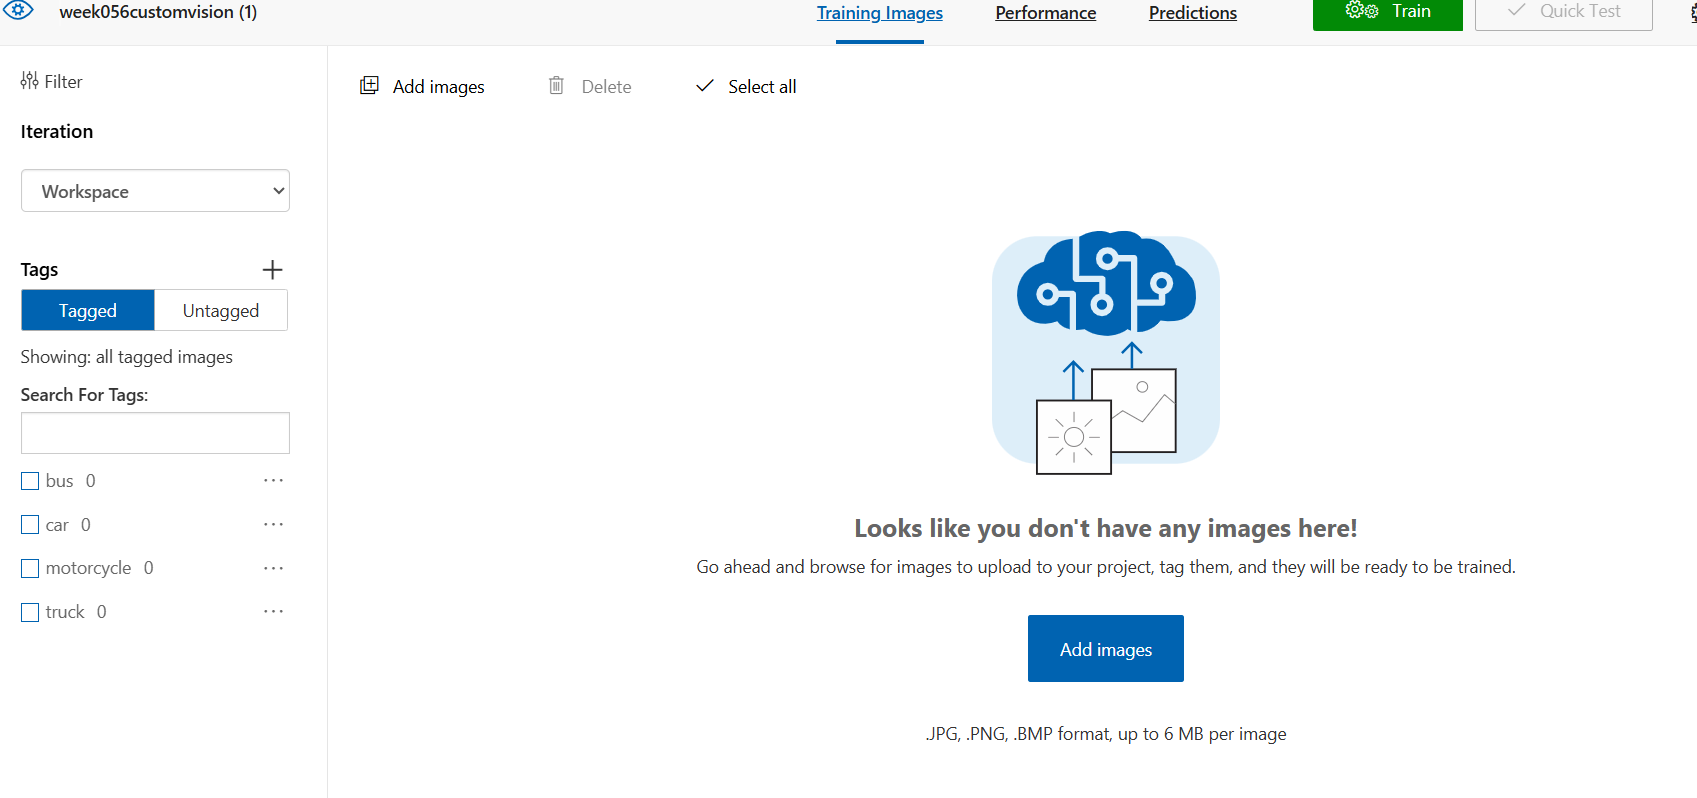

Upload and tag images


In [82]:
print(f"\n📊 Upload Summary:")
print(f"🖼️ Total images prepared: {len(image_list)}")
print(f"📌 Images using full-image fallback region: {full_image_region_count}")



📊 Upload Summary:
🖼️ Total images prepared: 201
📌 Images using full-image fallback region: 201


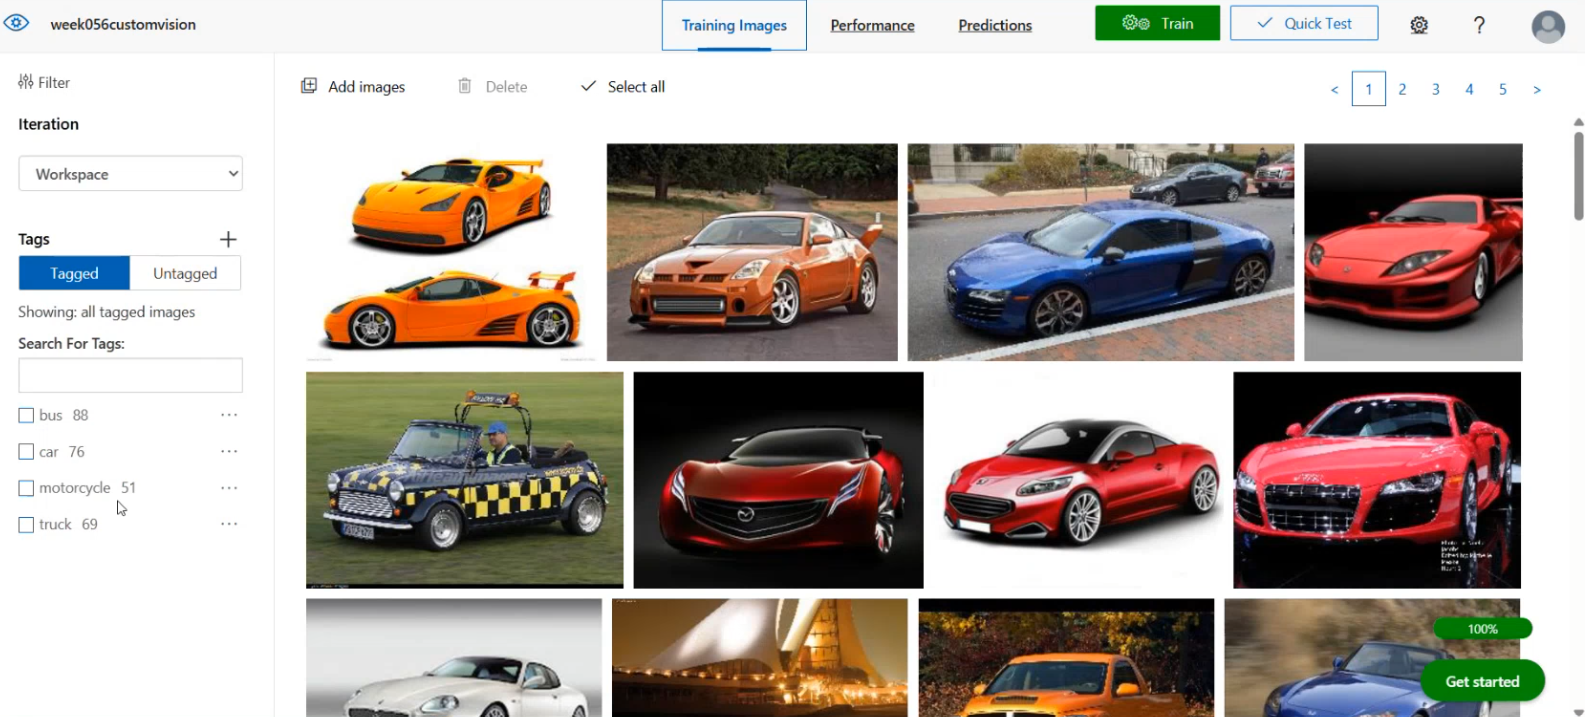

In [ ]:
def chunk_list(lst, chunk_size=50):
    for i in range(0, len(lst), chunk_size):
        yield lst[i:i + chunk_size]

print(f"\n🚀 Uploading {len(image_list)} images to Custom Vision...")

batch_num = 1
for batch in chunk_list(image_list):
    print(f"\n📦 Uploading batch {batch_num}...")
    upload_result = trainer.create_images_from_files(project.id, ImageFileCreateBatch(images=batch))

    if upload_result.is_batch_successful:
        print("✅ Batch uploaded successfully.")
    else:
        print("❌ Some images failed to upload.")
        for img in upload_result.images:
            print(f"Image status: {img.status}")

    batch_num += 1



This code will upload the images

In [6]:
import time

# Step 1: Start training
print("🚀 Starting training...")

iteration = trainer.train_project(project.id)


🚀 Starting training...


In [7]:
while (iteration.status != "Completed"):
    iteration = trainer.get_iteration(project.id, iteration.id)
    print ("Training status: " + iteration.status)
    time.sleep(20)


Training status: Training
Training status: Training
Training status: Training
Training status: Training
Training status: Training
Training status: Training
Training status: Training
Training status: Training
Training status: Training
Training status: Training
Training status: Training
Training status: Training
Training status: Training
Training status: Training
Training status: Completed


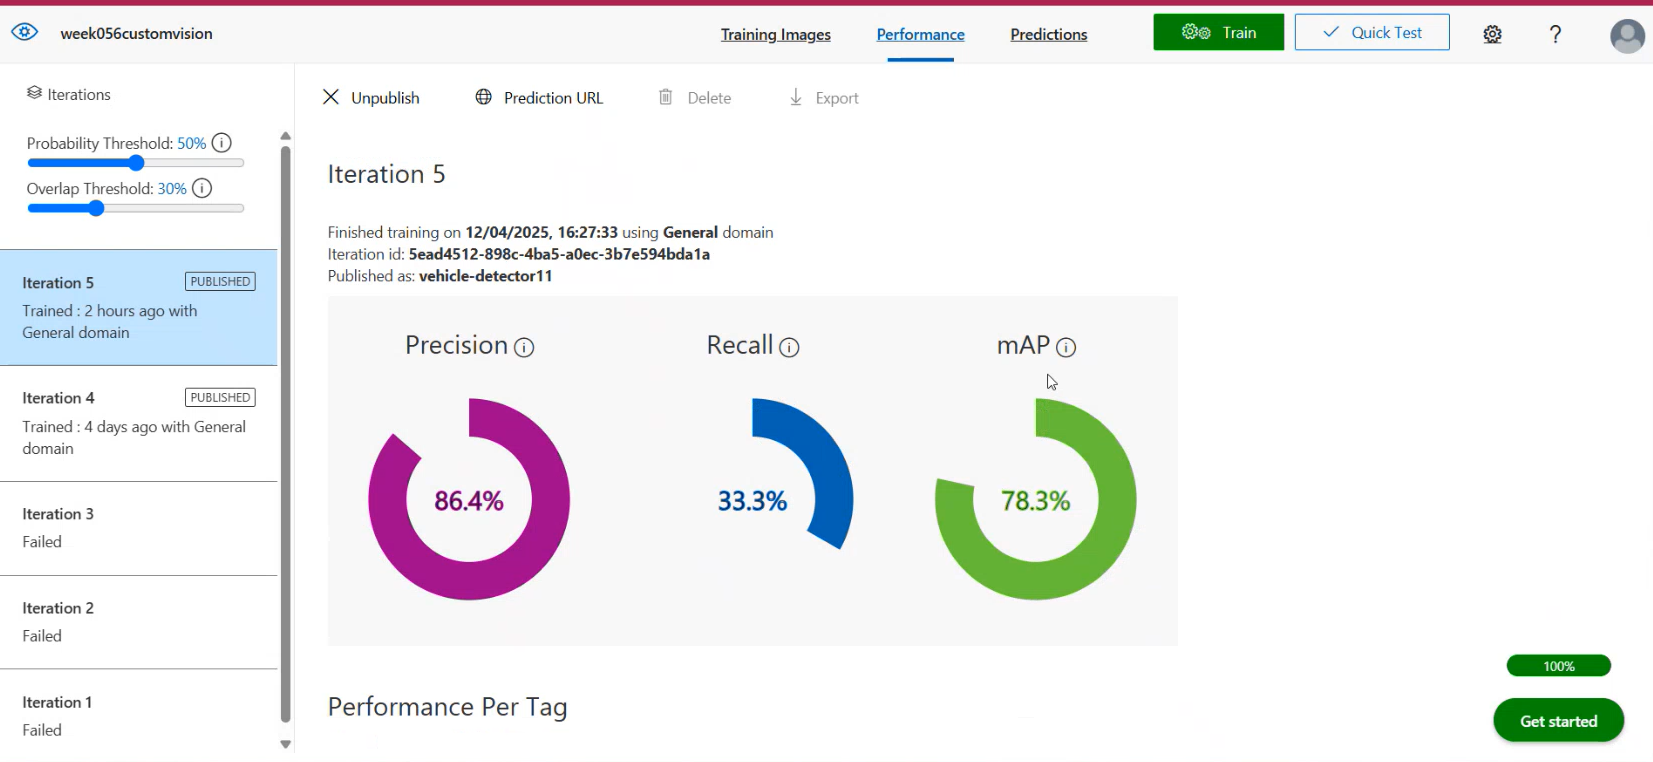

In [10]:
# The iteration is now trained. Publish it to the project e
# endpoint
publish_iteration_name = "vehicle-detector11"
prediction_Resource ="/subscriptions/db9d247d-c15a-4aae-aa5a-37419da2d49b/resourceGroups/deakinuni/providers/Microsoft.CognitiveServices/accounts/week05customvision-Prediction"

trainer.publish_iteration(project.id, iteration.id, publish_iteration_name, prediction_Resource)
print ("Done!")

Done!


# The iteration is now trained. Publish it to the project endpoint

## Prediction

In [11]:
import os
from azure.cognitiveservices.vision.customvision.prediction import CustomVisionPredictionClient
from msrest.authentication import ApiKeyCredentials


# Set the test image path (Windows path, raw string format)
test_image_path = r"C:\Users\sachi\OneDrive\Documents\Deakin\2025 T2\SIT788_Engineering_sol\assignment\5.2D\Dataset\Bus\Image_75.jpg"
publish_iteration_name = "vehicle-detector"  # Same as your published name


In [13]:
# Run prediction
publish_iteration_name = "vehicle-detector"  # Same as your published name

with open(test_image_path, mode="rb") as test_data:
    results = predictor.detect_image(project.id, publish_iteration_name, test_data)


In [14]:
# Display the results.    

for prediction in results.predictions:
    print("\t" + prediction.tag_name + ": {0:.2f}% bbox.left = {1:.2f}, bbox.top = {2:.2f}, bbox.width = {3:.2f}, bbox.height = {4:.2f}".format(prediction.probability * 100, prediction.bounding_box.left, prediction.bounding_box.top, prediction.bounding_box.width, prediction.bounding_box.height))

	bus: 79.79% bbox.left = 0.00, bbox.top = 0.04, bbox.width = 0.68, bbox.height = 0.91
	bus: 62.42% bbox.left = 0.33, bbox.top = 0.04, bbox.width = 0.67, bbox.height = 0.91
	truck: 0.78% bbox.left = 0.49, bbox.top = 0.07, bbox.width = 0.51, bbox.height = 0.86
	truck: 0.63% bbox.left = 0.00, bbox.top = 0.15, bbox.width = 0.71, bbox.height = 0.85


# Drawing prediction on the Image

In [15]:
from PIL import Image, ImageDraw, ImageFont
def draw_top_prediction_on_image(image_path, predictions, confidence_threshold=0.5):
    """
    Draw only the top (most confident) prediction on the image.

    Args:
        image_path (str): Path to the original image.
        predictions (list): Predictions from Custom Vision.
        confidence_threshold (float): Minimum confidence to draw.
    """
    # Filter predictions by confidence
    high_conf_preds = [p for p in predictions if p.probability >= confidence_threshold]

    if not high_conf_preds:
        print("⚠️ No prediction above confidence threshold.")
        return

    # Get the most confident one
    top_prediction = sorted(high_conf_preds, key=lambda x: x.probability, reverse=True)[0]

    # Open image
    image = Image.open(image_path)
    draw = ImageDraw.Draw(image)
    image_width, image_height = image.size

    # Bounding box in pixels
    left = top_prediction.bounding_box.left * image_width
    top = top_prediction.bounding_box.top * image_height
    width = top_prediction.bounding_box.width * image_width
    height = top_prediction.bounding_box.height * image_height
    right = left + width
    bottom = top + height

    # Optional font
    try:
        font = ImageFont.truetype("arial.ttf", 16)
    except:
        font = ImageFont.load_default()

    # Draw box and label
    draw.rectangle([(left, top), (right, bottom)], outline="red", width=3)
    label = f"{top_prediction.tag_name} ({top_prediction.probability * 100:.1f}%)"
    draw.text((left + 5, top - 15), label, fill="red", font=font)

    # Show result
    print(f"✅ Top Prediction: {label}")
    image.show()


In [16]:
with open(test_image_path, "rb") as test_data:
    results = predictor.detect_image(project.id, publish_iteration_name, test_data)

draw_top_prediction_on_image(test_image_path, results.predictions, confidence_threshold=0.5)


✅ Top Prediction: bus (79.8%)


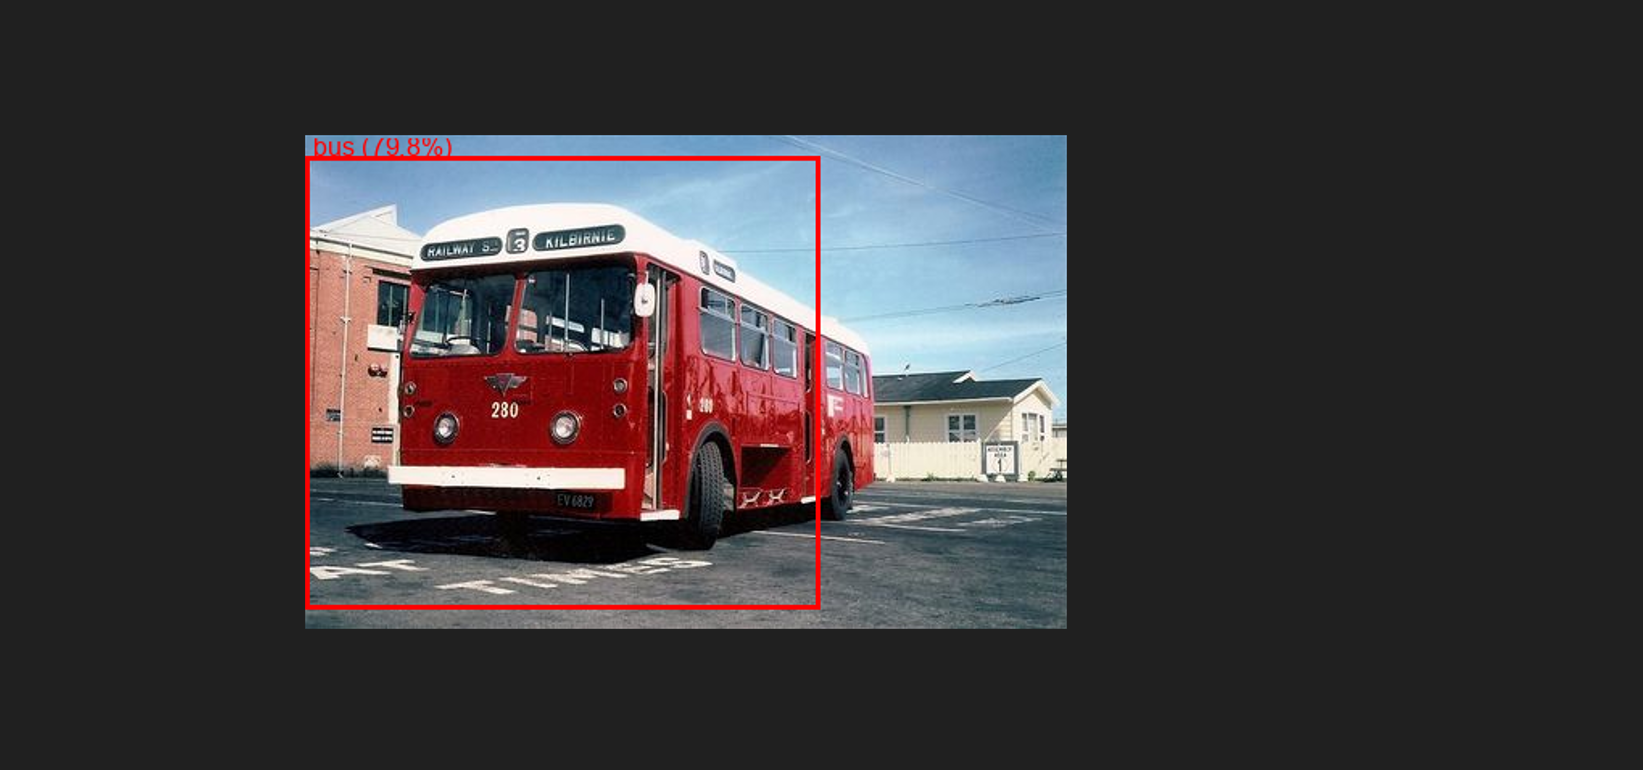

# Detect object in video

## Hint

- Download video or record one
- write code to convert video to images (from video get frames)
- apply object detection to all images and add bounding box
- Convert all images with bounding box to video (frame to video)


In [132]:
!pip install opencv-python pillow azure-cognitiveservices-vision-customvision


Defaulting to user installation because normal site-packages is not writeable


# Extract the Frame

In [17]:
import cv2
import os

def extract_frames(video_path, output_folder):
    os.makedirs(output_folder, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_path = os.path.join(output_folder, f"frame_{count:04d}.jpg")
        cv2.imwrite(frame_path, frame)
        count += 1
    cap.release()
    print(f"✅ Extracted {count} frames to: {output_folder}")


# Process Frame with prediction which we implemented above

In [18]:
from PIL import Image, ImageDraw, ImageFont
def process_frame_with_prediction(frame_path, output_path, predictor, project_id, iteration_name):
    from PIL import Image, ImageDraw, ImageFont

    # Run prediction
    with open(frame_path, "rb") as image_file:
        result = predictor.detect_image(project_id, iteration_name, image_file)

    predictions = result.predictions

    # ⚠️ Check if any predictions exist at all
    if not predictions:
        print(f"⚠️ No predictions for {frame_path}. Saving original.")
        Image.open(frame_path).save(output_path)
        return

    # ✅ Always use the top prediction (regardless of confidence)
    top_pred = sorted(predictions, key=lambda p: p.probability, reverse=True)[0]

    # Open the frame for drawing
    image = Image.open(frame_path)
    draw = ImageDraw.Draw(image)
    w, h = image.size

    # Convert relative coordinates to absolute pixels
    left = top_pred.bounding_box.left * w
    top = top_pred.bounding_box.top * h
    width = top_pred.bounding_box.width * w
    height = top_pred.bounding_box.height * h
    right = left + width
    bottom = top + height

    # Load font (fallback to default if missing)
    try:
        font = ImageFont.truetype("arial.ttf", 16)
    except:
        font = ImageFont.load_default()

    # Draw rectangle and label
    label = f"{top_pred.tag_name} ({top_pred.probability * 100:.1f}%)"
    draw.rectangle([(left, top), (right, bottom)], outline="red", width=3)
    draw.text((left + 5, top - 15), label, fill="red", font=font)

    # Save the processed frame
    image.save(output_path)


# Predicted frame back to video

In [19]:
def frames_to_video(frame_folder, output_video, fps=20):
    frame_files = sorted([f for f in os.listdir(frame_folder) if f.endswith(".jpg")])
    first_frame = cv2.imread(os.path.join(frame_folder, frame_files[0]))
    height, width, _ = first_frame.shape

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

    for f in frame_files:
        frame = cv2.imread(os.path.join(frame_folder, f))
        out.write(frame)

    out.release()
    print(f"✅ Video saved to {output_video}")


In [22]:
video_path = r"C:\Users\sachi\OneDrive\Documents\Deakin\2025 T2\SIT788_Engineering_sol\assignment\5.2D\Dataset\for vidoe\video.mp4"
frames_folder = "./frames1"
processed_folder = "./processed_frames1"
output_video_path = "output_annotated_video1.mp4"

# Extract frames
extract_frames(video_path, frames_folder)

# Process each frame
os.makedirs(processed_folder, exist_ok=True)
for frame_file in sorted(os.listdir(frames_folder)):
    input_frame = os.path.join(frames_folder, frame_file)
    output_frame = os.path.join(processed_folder, frame_file)
    #predictor = CustomVisionPredictionClient(ENDPOINT, credentials)

    process_frame_with_prediction(input_frame, output_frame, predictor, project.id, publish_iteration_name)

# Rebuild video
frames_to_video(processed_folder, output_video_path, fps=20)


✅ Extracted 1676 frames to: ./frames1
✅ Video saved to output_annotated_video1.mp4


Object Detection and Tracking Performance
The Azure Custom Vision model demonstrated reasonable accuracy in detecting objects when applied to individual video frames extracted at 20 FPS. The detection worked well when the object was clearly visible and similar to the training image. During video testing, the model was able to consistently identify the target object, simulating real-time tracking across sequential frames.

Limitations
Limited Accuracy in Multi-Object Scenes:

The model was trained on a very limited dataset, with mostly one image per object.

As a result, it tends to detect only one object, even when multiple similar objects are present.

This leads to false negatives, where other valid objects are missed.

False Positives:

The model occasionally detects objects in irrelevant regions, especially in cluttered or dynamic scenes, due to lack of diverse training data.

Speed and Real-Time Limitations:

Since prediction was done frame-by-frame using API calls (or model inference), processing speed can be slow if not optimized.

Not suitable for live object tracking without batching or edge deployment.

Potential Improvements
Dataset Enhancement:

Train the model with more images per object, covering different angles, lighting, and backgrounds.

Include images with multiple objects per frame to help the model learn spatial relationships.

Data Augmentation:

Apply techniques such as rotation, flipping, cropping, and brightness variation to improve generalization.

Model Fine-Tuning:

Use transfer learning to fine-tune the model with a larger or more representative dataset.

Consider increasing training epochs and using validation feedback.

Switch to a More Advanced Model:

Explore using YOLOv8, Detectron2, or OpenVINO for higher accuracy and real-time object detection if Azure's model doesn't meet performance requirements.

Edge Deployment:

Deploy the model locally for faster inference instead of sending every frame to the cloud.



# Link of video
https://deakin.au.panopto.com/Panopto/Pages/Viewer.aspx?id=5fa94bc5-ffc0-4266-ac60-b2bd00c40149